- consolidate functions into the [experiments_utils.py](./experiments_utils.py) file, and call the function here
- change from 100 trials to 1000 trials

In [3]:
from experiments_utils import *

In [ ]:
CURRENT_BOUNDS = (0.01, 1.5)
EPSILON = 1e-3

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]

# parameter setting
N_RUNS_A = 1000
A_BEAMLINE_LEN = 10



METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B", "2-point"),
    ("SLSQP", "2-point"),
    ("COBYLA", None),
    ("trust-constr", "2-point"),
]

A_VARS = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}

In [ ]:
# this is default version
METHOD_OPTIONS = {
    "L-BFGS-B": {
        "maxcor": 10,
        "ftol": 2.220446049250313e-09,
        "gtol": 1e-5,
        "eps": 1e-8,
        "maxfun": 15000,
        "maxiter": 15000,
        "maxls": 20,
    },
    "SLSQP": {
        "maxiter": 100,
        "ftol": 1e-6,
        "iprint": 1,
        "disp": False,
        "eps": 1.4901161193847656e-08,
        "finite_diff_rel_step": None,
        "workers": None,
    },
    "trust-constr": {
        "xtol": 1e-8,
        "gtol": 1e-8,
        "barrier_tol": 1e-8,
        "sparse_jacobian": None,
        "maxiter": 1000,
        "verbose": 0,
        "finite_diff_rel_step": None,
        "initial_constr_penalty": 1.0,
        "initial_tr_radius": 1.0,
        "initial_barrier_parameter": 0.1,
        "initial_barrier_tolerance": 0.1,
        "factorization_method": None,
        "disp": False,
        "workers": None,
    },
    "Nelder-Mead": {
        "maxiter": None,
        "maxfev": None,
        "disp": False,
        "return_all": False,
        "initial_simplex": None,
        "xatol": 1e-4,
        "fatol": 1e-4,
        "adaptive": False,
    },
    "COBYLA": {
        "rhobeg": 1.0,
        "tol": 1e-4,
        "maxiter": 1000,
        "disp": 0,
        "catol": None,
        "f_target": float("-inf"),
    },
}


▶ Scenario A — Nelder-Mead  (1000 runs)
  Nelder-Mead             run 1/1000  MSE=3.342e-09  nit=37  nfev=73   t=13.04s
  Nelder-Mead             run 2/1000  MSE=1.366e-08  nit=36  nfev=69   t=11.84s
  Nelder-Mead             run 3/1000  MSE=5.457e-09  nit=46  nfev=88   t=15.55s
  Nelder-Mead             run 4/1000  MSE=6.127e-09  nit=40  nfev=75   t=15.10s
  Nelder-Mead             run 5/1000  MSE=4.733e-09  nit=38  nfev=74   t=13.45s
  Nelder-Mead             run 6/1000  MSE=1.183e-08  nit=30  nfev=58   t=10.59s
  Nelder-Mead             run 7/1000  MSE=1.682e-08  nit=42  nfev=82   t=14.73s
  Nelder-Mead             run 8/1000  MSE=1.065e-08  nit=53  nfev=103  t=18.36s
  Nelder-Mead             run 9/1000  MSE=8.154e-09  nit=44  nfev=86   t=15.44s
  Nelder-Mead             run 10/1000  MSE=9.202e-09  nit=52  nfev=99   t=20.99s
  Nelder-Mead             run 11/1000  MSE=2.834e-09  nit=42  nfev=78   t=13.84s
  Nelder-Mead             run 12/1000  MSE=4.347e-09  nit=49  nfev=94   t=17.

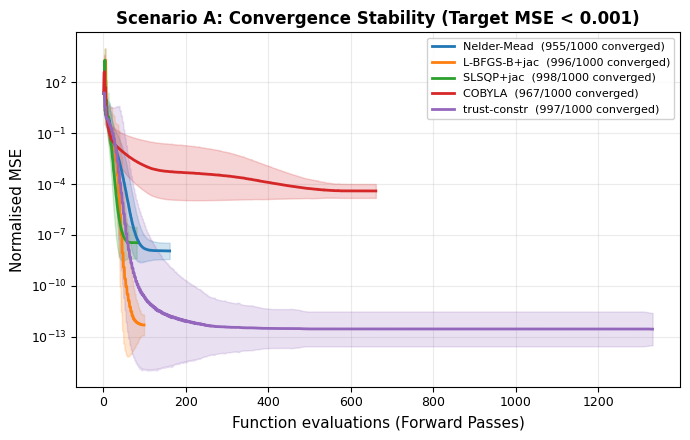

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.7298e-10     0.2913     0.2791
  L-BFGS-B+jac           1.7676e-16     0.7581     0.5891
  SLSQP+jac              3.0209e-13     0.2913     0.2791
  COBYLA                 3.9280e-09     0.7581     0.5891
  trust-constr           4.7706e-17     0.7581     0.5891

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: trust-constr,  MSE=4.7706e-17
    I=0.75807 A,  I2=0.58906 A


In [4]:
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS, A_BEAMLINE_LEN, METHODS_A,scale="log",METHOD_OPTIONS=METHOD_OPTIONS)
display_results(results_A, REF_I)

In [5]:
# save the results
experiment_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_results_v4.pkl")
save_results(results_A, df_A, final_summary, experiment_save_path)

In [9]:
# load the results
results_A, df_A, final_summary = load_results(experiment_save_path)

✓ experiment results loaded from c:\Users\yilu2\my_files\research\FELsim\experiment\../results/scenario_A_results_v4.pkl


give the **(alpha_x,alpha_y) scatter plot** and **MSE heatmap with iteration trajectories**

In [12]:
import importlib, experiments_utils
importlib.reload(experiments_utils)
from experiments_utils import *

c:\Users\yilu2\my_files\research\FELsim\backend


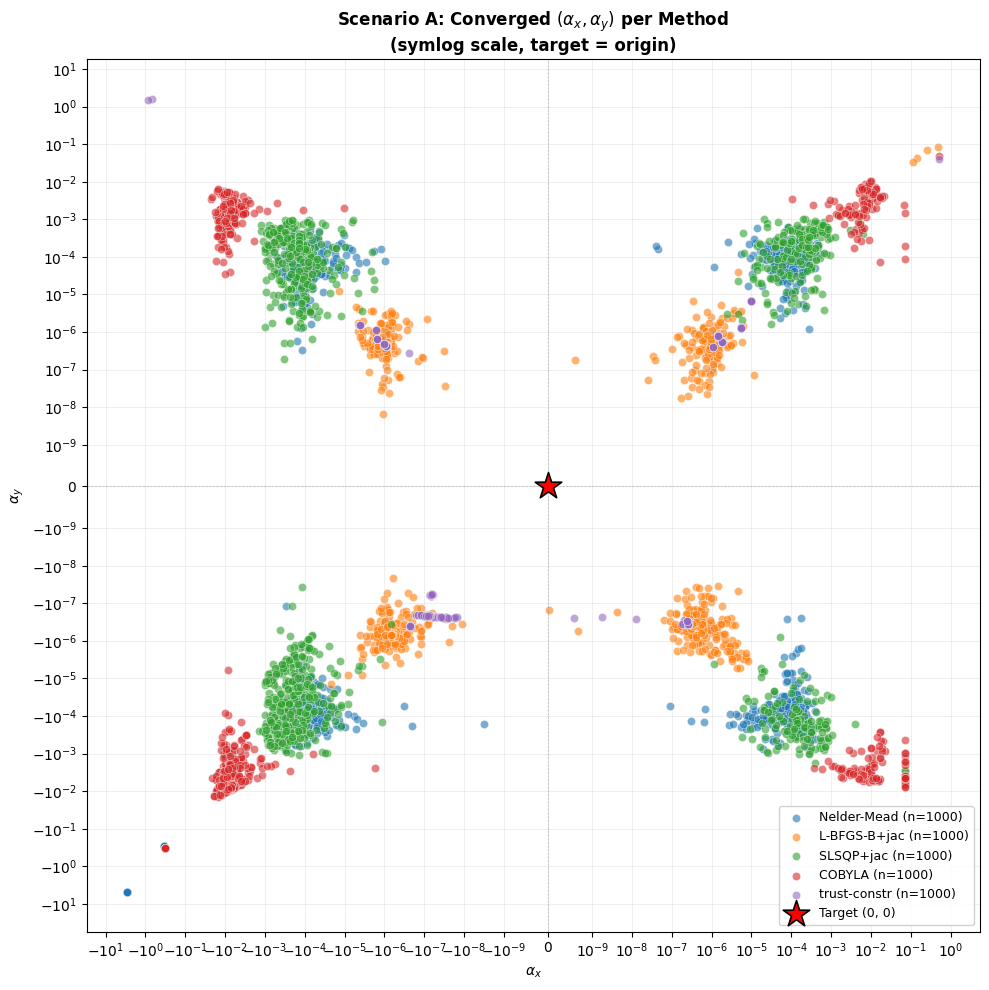

In [13]:
# scatter plot
# parameter setting
N_GRID = 100
plot_MSE(df_A)

  row 5/100   104s
  row 10/100   199s
  row 15/100   290s
  row 20/100   382s
  row 25/100   473s
  row 30/100   567s
  row 35/100   658s
  row 40/100   750s
  row 45/100   840s
  row 50/100   929s
  row 55/100   1020s
  row 60/100   1110s
  row 65/100   1201s
  row 70/100   1291s
  row 75/100   1381s
  row 80/100   1470s
  row 85/100   1560s
  row 90/100   1650s
  row 95/100   1740s
  row 100/100   1829s
Grid 100 100, MSE range [6.38e-06, 3.21e+03]


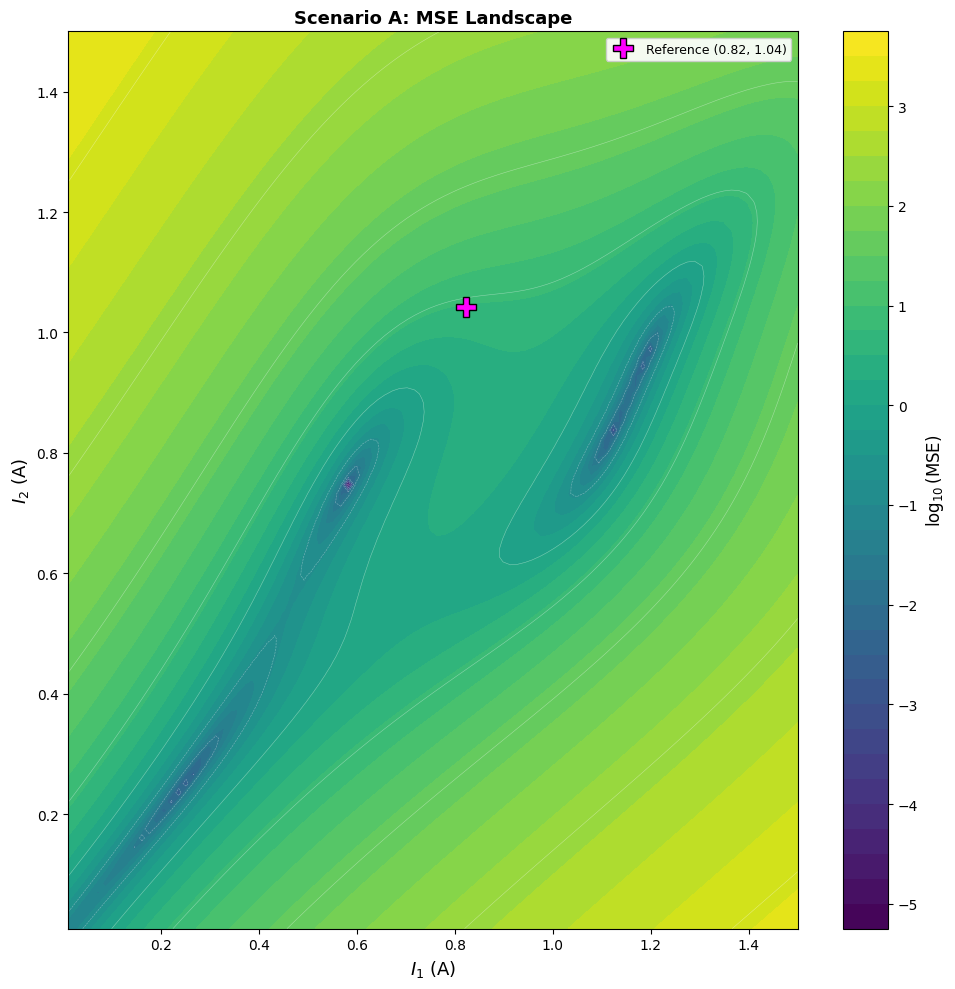

In [14]:
# save the landscape information
landscape_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_landscape_v4.pkl")
save_landscape(CURRENT_BOUNDS,  A_BEAMLINE_LEN, A_VARS, A_OBJ, N_GRID, landscape_save_path)
plot_contour(landscape_save_path)

10 start points:
 [[0.277 0.963]
 [0.706 0.562]
 [0.539 1.188]
 [1.359 0.274]
 [0.983 0.454]
 [1.451 1.381]
 [0.957 1.132]
 [0.778 1.241]
 [0.678 0.515]
 [0.424 0.347]]
Nelder-Mead    start1 (0.28,0.96)  steps= 44  MSE=2.21e-09  x=[0.2457 0.2501]
Nelder-Mead    start2 (0.71,0.56)  steps= 26  MSE=1.97e-08  x=[0.5815 0.747 ]
Nelder-Mead    start3 (0.54,1.19)  steps= 39  MSE=2.47e-08  x=[1.1177 0.8281]
Nelder-Mead    start4 (1.36,0.27)  steps= 59  MSE=1.96e-09  x=[0.2456 0.2501]
Nelder-Mead    start5 (0.98,0.45)  steps= 33  MSE=2.98e-08  x=[0.5815 0.747 ]
Nelder-Mead    start6 (1.45,1.38)  steps= 42  MSE=3.90e-08  x=[1.1177 0.8281]
Nelder-Mead    start7 (0.96,1.13)  steps= 25  MSE=1.46e-08  x=[1.1902 0.9582]
Nelder-Mead    start8 (0.78,1.24)  steps= 30  MSE=1.65e-09  x=[1.1177 0.8281]
Nelder-Mead    start9 (0.68,0.51)  steps= 29  MSE=5.30e-08  x=[0.5815 0.747 ]
Nelder-Mead    start10 (0.42,0.35)  steps= 37  MSE=6.12e-09  x=[0.2456 0.2501]
L-BFGS-B       start1 (0.28,0.96)  steps= 11  MSE=

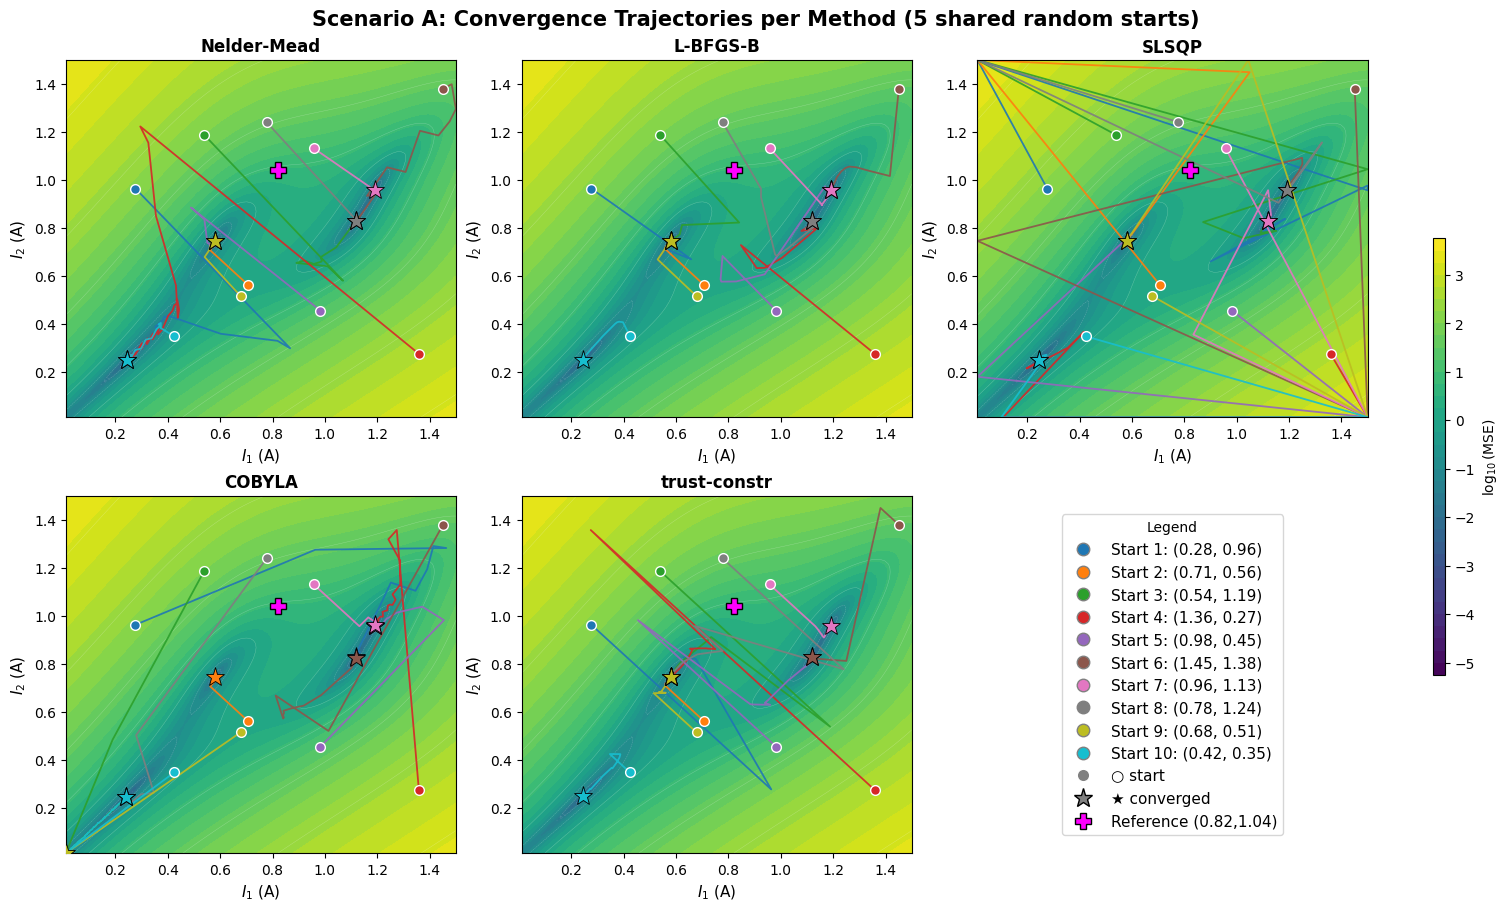

In [15]:
N_STARTS = 10
trajectories_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_trajectories_v4.pkl")
save_trajectories(A_BEAMLINE_LEN, N_STARTS, A_VARS, A_OBJ, METHODS_A, METHOD_OPTIONS, trajectories_save_path)
plot_trajectories(landscape_save_path, trajectories_save_path)